# Assignment 5

# Question 1 - NN Basics

In [7]:
install.packages(c("neuralnet", "nnet", "ggplot2"))
library(neuralnet)
library(nnet)
library(ggplot2)


Warning message:
"package 'nnet' is in use and will not be installed"
also installing the dependency 'Deriv'




package 'Deriv' successfully unpacked and MD5 sums checked
package 'neuralnet' successfully unpacked and MD5 sums checked
package 'ggplot2' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\VICTOR\AppData\Local\Temp\RtmpaEtAER\downloaded_packages



Adjuntando el paquete: 'ggplot2'


The following object is masked from 'package:randomForest':

    margin




## I. Fitting Data

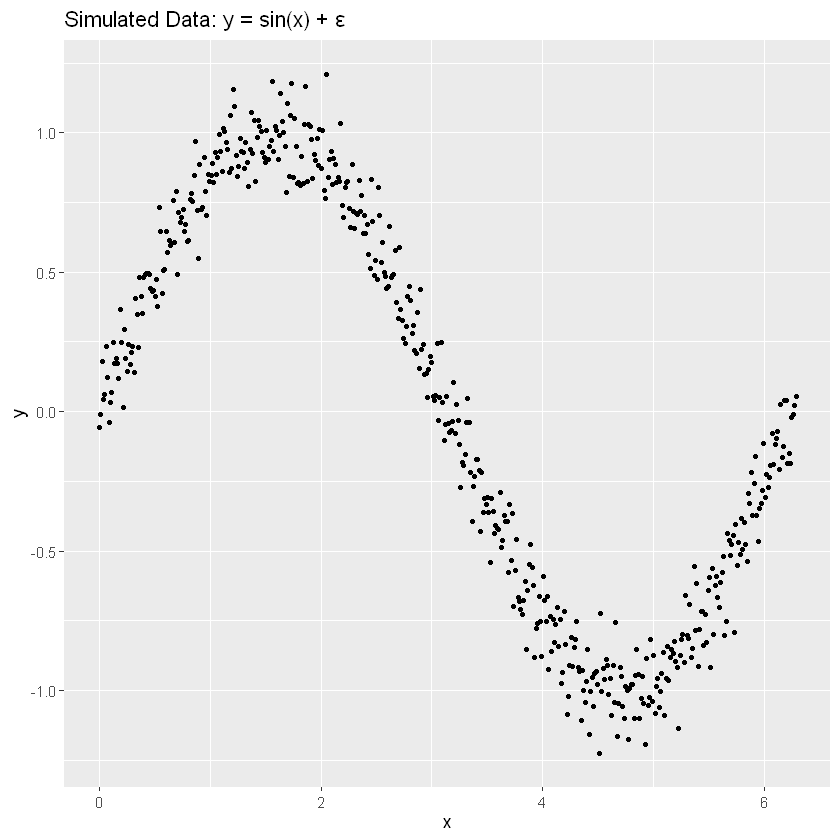

In [8]:
set.seed(123)

n <- 500
x <- seq(0, 2*pi, length.out = n)
eps <- rnorm(n, 0, 0.1)
y <- sin(x) + eps

data <- data.frame(x = x, y = y)

ggplot(data, aes(x, y)) +
  geom_point(size = 1) +
  ggtitle("Simulated Data: y = sin(x) + ε")


In [ ]:
logistic <- function(x) 1 / (1 + exp(-x))
tanh_act <- function(x) tanh(x)
relu <- function(x) ifelse(x > 0, x, 0)
train_nn <- function(act_function) {
  neuralnet(
    y ~ x,
    data = data,
    hidden = c(50, 50, 50),
    act.fct = act_function,
    linear.output = TRUE,
    stepmax = 1e+07
  )
}
nn_logistic <- train_nn(logistic)
nn_tanh     <- train_nn(tanh_act)
nn_relu     <- train_nn(relu)
pred_log <- compute(nn_logistic, data.frame(x=x))$net.result
pred_tanh <- compute(nn_tanh, data.frame(x=x))$net.result
pred_relu <- compute(nn_relu, data.frame(x=x))$net.result
plot_df <- data.frame(
  x = rep(x, 4),
  y = c(y, pred_log, pred_tanh, pred_relu),
  model = factor(rep(c("data","logistic","tanh","relu"), each=n),
                 levels = c("data","logistic","tanh","relu"))
)

ggplot(plot_df, aes(x, y, color = model)) +
  geom_point(size=0.8) +
  geom_line() +
  ggtitle("NN Fits with Different Activations")


In [ ]:
install.packages("keras")
library(keras)


In [ ]:
model_mixed <- keras_model_sequential() %>%
  layer_dense(units = 50, activation = "relu", input_shape = 1) %>%
  layer_dense(units = 50, activation = "tanh") %>%
  layer_dense(units = 50, activation = "sigmoid") %>%
  layer_dense(units = 1)

model_mixed %>% compile(
  optimizer = optimizer_adam(learning_rate = 0.01),
  loss = "mse"
)

history <- model_mixed %>% fit(
  x, y,
  epochs = 200,
  batch_size = 32,
  verbose = 0
)

pred_mixed <- model_mixed %>% predict(x)
plot(x, y, pch = 20, main = "Mixed Activation NN")
lines(x, pred_mixed, col = "blue", lwd = 2)


## II. Learning-rate

In [ ]:
lrs <- c(0.0001, 0.001, 0.01, 0.1)
train_lr <- function(lr, layers) {
  model <- keras_model_sequential() %>%
    layer_dense(units = 50, activation = "tanh", input_shape = 1)

  for (i in 2:layers) {
    model <- model %>%
      layer_dense(units = 50, activation = "tanh")
  }

  model <- model %>% layer_dense(units = 1)

  model %>% compile(
    optimizer = optimizer_adam(learning_rate = lr),
    loss = "mse"
  )

  history <- model %>% fit(
    x, y,
    epochs = 200,
    batch_size = 32,
    verbose = 0
  )

  preds <- model %>% predict(x)
  return(preds)
}


In [ ]:
preds_1 <- lapply(lrs, train_lr, layers = 1)
plot(x, y, pch=20, main="1 hidden layer: learning rates")
cols <- c("red","blue","green","purple")
for (i in 1:4)
  lines(x, preds_1[[i]], col=cols[i], lwd=2)
legend("topright", legend=paste("lr=", lrs), col=cols, lwd=2)


In [ ]:
preds_2 <- lapply(lrs, train_lr, layers = 2)

plot(x, y, pch=20, main="2 hidden layers: learning rates")
for (i in 1:4)
  lines(x, preds_2[[i]], col=cols[i], lwd=2)
legend("topright", legend=paste("lr=", lrs), col=cols, lwd=2)


In [ ]:
preds_3 <- lapply(lrs, train_lr, layers = 3)

plot(x, y, pch=20, main="3 hidden layers: learning rates")
for (i in 1:4)
  lines(x, preds_3[[i]], col=cols[i], lwd=2)
legend("topright", legend=paste("lr=", lrs), col=cols, lwd=2)


# Question 2 - DML 

In [1]:
install.packages(c("hdm", "glmnet", "randomForest", "nnet", "sandwich", "xtable"), repos = "http://cran.us.r-project.org")
library(hdm)
library(glmnet)
library(randomForest)
library(nnet)
library(sandwich)
library(xtable)

set.seed(123)

package 'hdm' successfully unpacked and MD5 sums checked
package 'glmnet' successfully unpacked and MD5 sums checked
package 'randomForest' successfully unpacked and MD5 sums checked
package 'nnet' successfully unpacked and MD5 sums checked
package 'sandwich' successfully unpacked and MD5 sums checked
package 'xtable' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\VICTOR\AppData\Local\Temp\RtmpaEtAER\downloaded_packages


Cargando paquete requerido: Matrix

Loaded glmnet 4.1-10

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.



## I. Cleaning and set-up

In [4]:
# --- I. Data cleaning and setup ---

data <- read.table("C:/Users/VICTOR/Documents/GitHub/UP_courses/penn_jae.dat.txt", header = TRUE)

# Keep tg = 0 or 4
data <- subset(data, tg %in% c(0,4))

# Define treatment variable
data$T4 <- ifelse(data$tg == 4, 1, 0)

# Define outcome (log of inuidur1)
data$y <- log(data$inuidur1)

# Dummies for dep
data$dep <- as.factor(data$dep)
dep_dummies <- model.matrix(~ dep - 1, data)
colnames(dep_dummies) <- gsub("dep", "dep_", colnames(dep_dummies))

# Combine into final dataset
data <- cbind(data, dep_dummies)

# Define feature matrix X
xvars <- c("female","black","othrace",
           "dep_1","dep_2",
           "q2","q3","q4","q5","q6",
           "recall","agelt35","agegt54",
           "durable","nondurable","lusd","husd")

X <- as.matrix(data[, xvars])
y <- as.matrix(data$y)
d <- as.matrix(data$T4)

cat("\nData ready. N =", nrow(X), ", K =", ncol(X), "\n")




Data ready. N = 5099 , K = 17 


## II. Debiased ML

In [5]:
# =====================================================
# II. Debiased Machine Learning (with cross-fitting)
# =====================================================

DML2.for.PLM <- function(x, d, y, dreg, yreg, nfold=5) {
  nobs <- nrow(x)
  foldid <- rep(1:nfold, length.out = nobs)
  foldid <- sample(foldid)
  I <- split(1:nobs, foldid)
  ytil <- dtil <- rep(NA, nobs)
  cat("Fold: ")
  for (b in 1:length(I)) {
    cat(b, " ")
    dfit <- dreg(x[-I[[b]],], d[-I[[b]]])
    yfit <- yreg(x[-I[[b]],], y[-I[[b]]])
    dhat <- predict(dfit, x[I[[b]],])
    yhat <- predict(yfit, x[I[[b]],])
    dtil[I[[b]]] <- d[I[[b]]] - dhat
    ytil[I[[b]]] <- y[I[[b]]] - yhat
  }
  rfit <- lm(ytil ~ dtil)
  coef.est <- coef(rfit)[2]
  se <- sqrt(vcovHC(rfit)[2,2])
  return(list(coef.est=coef.est, se=se, dtil=dtil, ytil=ytil))
}


# --- OLS ---
cat("\nDML with OLS\n")
dreg <- function(x,d){ glmnet(x, d, lambda=0) }
yreg <- function(x,y){ glmnet(x, y, lambda=0) }
DML_OLS <- DML2.for.PLM(X, d, y, dreg, yreg, nfold=10)

# --- Lasso ---
cat("\nDML with Lasso\n")
dreg <- function(x,d){ rlasso(x,d, post=FALSE) }
yreg <- function(x,y){ rlasso(x,y, post=FALSE) }
DML_Lasso <- DML2.for.PLM(X, d, y, dreg, yreg, nfold=10)

# --- Random Forest ---
cat("\nDML with Random Forest\n")
dreg <- function(x,d){ randomForest(x, d) }
yreg <- function(x,y){ randomForest(x, y) }
DML_RF <- DML2.for.PLM(X, d, y, dreg, yreg, nfold=10)

# --- Neural Network (NN/RF) ---
cat("\nDML with NN for Y and RF for D\n")
dreg <- function(x,d){ randomForest(x, d) }
yreg <- function(x,y){ nnet(x, y, size=5, linout=TRUE, maxit=500, trace=FALSE) }
DML_NN_RF <- DML2.for.PLM(X, d, y, dreg, yreg, nfold=10)

# --- Neural Network (NN/NN) ---
cat("\nDML with NN for both Y and D\n")
dreg <- function(x,d){ nnet(x, d, size=5, linout=TRUE, maxit=500, trace=FALSE) }
yreg <- function(x,y){ nnet(x, y, size=5, linout=TRUE, maxit=500, trace=FALSE) }
DML_NN_NN <- DML2.for.PLM(X, d, y, dreg, yreg, nfold=10)

# --- RMSEs ---
prRes.D <- c(mean(DML_OLS$dtil^2),
             mean(DML_Lasso$dtil^2),
             mean(DML_RF$dtil^2),
             mean(DML_NN_RF$dtil^2),
             mean(DML_NN_NN$dtil^2))
prRes.Y <- c(mean(DML_OLS$ytil^2),
             mean(DML_Lasso$ytil^2),
             mean(DML_RF$ytil^2),
             mean(DML_NN_RF$ytil^2),
             mean(DML_NN_NN$ytil^2))

prRes <- rbind(sqrt(prRes.D), sqrt(prRes.Y))
rownames(prRes) <- c("RMSE D", "RMSE Y")
colnames(prRes) <- c("OLS", "Lasso", "RF", "NN/RF", "NN/NN")

# --- Table ---
table <- matrix(NA, nrow=5, ncol=4)
colnames(table) <- c("Estimate","Std. Error","RMSE Y","RMSE D")
rownames(table) <- c("OLS","Lasso","RF","NN/RF","NN/NN")

table[,1] <- c(DML_OLS$coef.est, DML_Lasso$coef.est, DML_RF$coef.est, DML_NN_RF$coef.est, DML_NN_NN$coef.est)
table[,2] <- c(DML_OLS$se, DML_Lasso$se, DML_RF$se, DML_NN_RF$se, DML_NN_NN$se)
table[,3] <- prRes["RMSE Y",]
table[,4] <- prRes["RMSE D",]

cat("\n=== Results: DML with Cross-Fitting ===\n")
print(round(table, 4))


DML with OLS
Fold: 1  2  3  4  5  6  7  8  9  10  
DML with Lasso
Fold: 1  2  3  4  5  6  7  8  9  10  
DML with Random Forest
Fold: 1  

Warning message in randomForest.default(x, d):
"The response has five or fewer unique values.  Are you sure you want to do regression?"


2  

Warning message in randomForest.default(x, d):
"The response has five or fewer unique values.  Are you sure you want to do regression?"


3  

...

9  

Warning message in randomForest.default(x, d):
"The response has five or fewer unique values.  Are you sure you want to do regression?"


10  

Warning message in randomForest.default(x, d):
"The response has five or fewer unique values.  Are you sure you want to do regression?"



DML with NN for both Y and D
Fold: 1  2  3  4  5  6  7  8  9  10  
=== Results: DML with Cross-Fitting ===
      Estimate Std. Error RMSE Y RMSE D
OLS    -0.0733     0.0351 1.1951 0.4751
Lasso  -0.0787     0.0353 1.1984 0.4746
RF     -0.0775     0.0350 1.2067 0.4817
NN/RF  -0.0706     0.0350 1.2145 0.4825
NN/NN  -0.0616     0.0348 1.2167 0.4855


## III. No cross-fitting

In [6]:
# =====================================================
# III. No cross-fitting (train and predict on same data)
# =====================================================

DML_noCF <- function(x, d, y, dreg, yreg) {
  dfit <- dreg(x, d)
  yfit <- yreg(x, y)
  dhat <- predict(dfit, x)
  yhat <- predict(yfit, x)
  dtil <- d - dhat
  ytil <- y - yhat
  rfit <- lm(ytil ~ dtil)
  coef.est <- coef(rfit)[2]
  se <- sqrt(vcovHC(rfit)[2,2])
  return(list(coef.est=coef.est, se=se, dtil=dtil, ytil=ytil))
}

# --- Run all models without CF ---
noCF.OLS <- DML_noCF(X, d, y, function(x,d){glmnet(x,d,lambda=0)}, function(x,y){glmnet(x,y,lambda=0)})
noCF.Lasso <- DML_noCF(X, d, y, function(x,d){rlasso(x,d)}, function(x,y){rlasso(x,y)})
noCF.RF <- DML_noCF(X, d, y, function(x,d){randomForest(x,d)}, function(x,y){randomForest(x,y)})
noCF.NN_RF <- DML_noCF(X, d, y, function(x,d){randomForest(x,d)}, function(x,y){nnet(x,y,size=5,linout=TRUE,maxit=500,trace=FALSE)})
noCF.NN_NN <- DML_noCF(X, d, y, function(x,d){nnet(x,d,size=5,linout=TRUE,maxit=500,trace=FALSE)}, function(x,y){nnet(x,y,size=5,linout=TRUE,maxit=500,trace=FALSE)})

# --- RMSE comparison ---
prRes.D.noCF <- c(mean(noCF.OLS$dtil^2), mean(noCF.Lasso$dtil^2), mean(noCF.RF$dtil^2), mean(noCF.NN_RF$dtil^2), mean(noCF.NN_NN$dtil^2))
prRes.Y.noCF <- c(mean(noCF.OLS$ytil^2), mean(noCF.Lasso$ytil^2), mean(noCF.RF$ytil^2), mean(noCF.NN_RF$ytil^2), mean(noCF.NN_NN$ytil^2))

table.noCF <- cbind(
  Estimate = c(noCF.OLS$coef.est, noCF.Lasso$coef.est, noCF.RF$coef.est, noCF.NN_RF$coef.est, noCF.NN_NN$coef.est),
  SE = c(noCF.OLS$se, noCF.Lasso$se, noCF.RF$se, noCF.NN_RF$se, noCF.NN_NN$se),
  RMSE_Y = sqrt(prRes.Y.noCF),
  RMSE_D = sqrt(prRes.D.noCF)
)
rownames(table.noCF) <- c("OLS","Lasso","RF","NN/RF","NN/NN")

cat("\n=== Results: DML without Cross-Fitting ===\n")
print(round(table.noCF, 4))


Warning message in randomForest.default(x, d):
"The response has five or fewer unique values.  Are you sure you want to do regression?"
Warning message in rfout$mse/(var(y) * (n - 1)/n):
"Reciclar un array de longitud 1 en la aritmética de vector-array ha sido discontinuado
  Utilice c() o as.vector() en su lugar."
Warning message in rfout$mse/(var(y) * (n - 1)/n):
"Reciclar un array de longitud 1 en la aritmética de vector-array ha sido discontinuado
  Utilice c() o as.vector() en su lugar."
Warning message in randomForest.default(x, d):
"The response has five or fewer unique values.  Are you sure you want to do regression?"
Warning message in rfout$mse/(var(y) * (n - 1)/n):
"Reciclar un array de longitud 1 en la aritmética de vector-array ha sido discontinuado
  Utilice c() o as.vector() en su lugar."



=== Results: DML without Cross-Fitting ===
      Estimate     SE RMSE_Y RMSE_D
OLS    -0.0726 0.0351 1.1905 0.4734
Lasso  -0.0806 0.0353 1.1971 0.4745
RF     -0.0758 0.0354 1.1161 0.4450
NN/RF  -0.0814 0.0366 1.1636 0.4451
NN/NN  -0.0871 0.0350 1.1663 0.4665
